In [1]:
!pip install transformers torch pandas scikit-learn matplotlib seaborn kagglehub

In [3]:
import pandas as pd
import os

# Dataset ka direct web link download karte hain Colab par
print("Downloading dataset directly to Colab...")
# The previous wget command failed with a 404. It appears the file is already available locally.
# Using the local file instead.
DATASET_FILE = "aa_dataset-tickets-multi-lang-5-2-50-version.csv"

# Add a check to inspect the downloaded file
if not os.path.exists(DATASET_FILE) or os.stat(DATASET_FILE).st_size == 0:
    print(f"Error: {DATASET_FILE} was not found or is empty. Please ensure the file is present.")
    # Optionally, you can exit or raise an error here if the file is critical
else:
    print(f"Dataset '{DATASET_FILE}' found locally. First 5 lines:")
    !head -n 5 {DATASET_FILE}

    # Data load aur clean karein
    df = pd.read_csv(DATASET_FILE)

    # Columns ko map karein
    df = df.rename(columns={"body": "ticket_text", "queue": "true_tag"})
    df = df.dropna(subset=['ticket_text', 'true_tag'])

    # Unique tags dynamically save karein
    ALLOWED_TAGS = df['true_tag'].unique().tolist()

    # Testing ke liye 50 rows lein (Colab GPU par yeh seconds mein chal jayegi)
    df = df.head(50).copy()

    print(f"Dataset Loaded Successfully! Total Samples: {len(df)}")
    print("Available Taxonomy Tags:", ALLOWED_TAGS)
    df[['ticket_text', 'true_tag']].head()


Dataset 'aa_dataset-tickets-multi-lang-5-2-50-version.csv' found locally. First 5 lines:
subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\n\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.","Vielen Dank für die

In [4]:
import torch
from transformers import pipeline

print("Initializing local LLM Inference Pipeline on Colab GPU...")

# Model setup with GPU acceleration
llm_pipeline = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,  # T4 GPU par speed barhanay ke liye float16 use kiya hai
    device_map="auto"
)

Initializing local LLM Inference Pipeline on Colab GPU...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [5]:
def build_zero_shot_prompt(ticket):
    """Zero-shot prompt generation with structural output guidelines."""
    return (
        "You are an expert AI support ticket classification engine.\n"
        f"Analyze the ticket text and assign the TOP 3 most probable tags from this list: {', '.join(ALLOWED_TAGS)}.\n"
        "Order them by relevance (highest first).\n\n"
        "Rules:\n"
        "1. Output ONLY a comma-separated list of the top 3 tags.\n"
        "2. Do not explain, do not add conversational preamble.\n\n"
        f"Ticket: '{ticket}'\n"
        "Top 3 Tags:"
    )

def build_few_shot_prompt(ticket):
    """Few-shot prompt generation with contextual learning examples."""
    return (
        "You are an expert AI support ticket classification engine.\n"
        f"Analyze the ticket text and assign the TOP 3 most probable tags from this list: {', '.join(ALLOWED_TAGS)}.\n"
        "Order them by relevance (highest first).\n\n"
        "Rules:\n"
        "1. Output ONLY a comma-separated list of the top 3 tags.\n\n"
        "Example 1:\n"
        "Ticket: 'I want to cancel my auto-renewal and switch to a cheaper monthly plan.'\n"
        "Top 3 Tags: Billing and Payments, Sales and Pre-Sales, Technical Support\n\n"
        "Example 2:\n"
        "Ticket: 'The login button is grayed out and unresponsive on my mobile app browser.'\n"
        "Top 3 Tags: Technical Support, Sales and Pre-Sales, Returns and Exchanges\n\n"
        f"Ticket: '{ticket}'\n"
        "Top 3 Tags:"
    )

def process_llm_classification(prompt):
    """Executes model inference and formats output array."""
    outputs = llm_pipeline(
        prompt,
        max_new_tokens=25,
        temperature=0.1,  # Predictability maintain karne ke liye low temperature
        do_sample=False
    )
    generated_text = outputs[0]['generated_text']
    raw_prediction = generated_text.split("Top 3 Tags:")[-1].strip()
    predicted_list = [tag.strip() for tag in raw_prediction.split(",")]

    # Fallback padding agar model 3 tags se kam return kare
    while len(predicted_list) < 3:
        predicted_list.append("Unclassified")
    return predicted_list[:3]

In [6]:
print("Processing Zero-Shot Inference Engine...")
df['zero_shot_top_3'] = df['ticket_text'].apply(lambda x: process_llm_classification(build_zero_shot_prompt(x)))
df['zero_shot_top_1'] = df['zero_shot_top_3'].apply(lambda x: x[0])

print("Processing Few-Shot Inference Engine...")
df['few_shot_top_3'] = df['ticket_text'].apply(lambda x: process_llm_classification(build_few_shot_prompt(x)))
df['few_shot_top_1'] = df['few_shot_top_3'].apply(lambda x: x[0])

df[['ticket_text', 'true_tag', 'zero_shot_top_3', 'few_shot_top_3']].head()

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Processing Zero-Shot Inference Engine...


[transformers] Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=25) and `max_length

Processing Few-Shot Inference Engine...


[transformers] Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

,ticket_text,true_tag,zero_shot_top_3,few_shot_top_3
0,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,"[Technical Support, Billing and Payments, Sale...","[IT Support, Service Outages and Maintenance, ..."
1,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,"[Technical Support, Billing and Payments, Serv...","[Service Outages and Maintenance, Technical Su..."
2,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,"[Product Support, Technical Support, Service O...","[Product Support, Technical Support, Customer ..."
3,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,"[Billing and Payments, Technical Support, Serv...","[Billing and Payments, Returns and Exchanges, ..."
4,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,"[Technical Support, Billing and Payments, Cust...","[Product Support, Technical Support, Returns a..."


In [7]:
from sklearn.metrics import classification_report, accuracy_score

print("=== ZERO-SHOT CLASSIFICATION REPORT (Top-1 Category) ===")
print(classification_report(df['true_tag'], df['zero_shot_top_1'], labels=ALLOWED_TAGS, zero_division=0))

print("\n=== FEW-SHOT CLASSIFICATION REPORT (Top-1 Category) ===")
print(classification_report(df['true_tag'], df['few_shot_top_1'], labels=ALLOWED_TAGS, zero_division=0))

def calculate_top3_accuracy(dataframe, prediction_column):
    hits = sum(row['true_tag'] in row[prediction_column] for idx, row in dataframe.iterrows())
    return (hits / len(dataframe)) * 100

zero_shot_top3_acc = calculate_top3_accuracy(df, 'zero_shot_top_3')
few_shot_top3_acc = calculate_top3_accuracy(df, 'few_shot_top_3')

print("\n=== TOP-3 ARCHITECTURAL METRICS ===")
print(f"Zero-Shot Top-3 Inclusion Accuracy: {zero_shot_top3_acc:.2f}%")
print(f"Few-Shot Top-3 Inclusion Accuracy:  {few_shot_top3_acc:.2f}%")

=== ZERO-SHOT CLASSIFICATION REPORT (Top-1 Category) ===
                                 precision    recall  f1-score   support

              Technical Support       0.48      0.84      0.62        19
          Returns and Exchanges       0.00      0.00      0.00         4
           Billing and Payments       1.00      1.00      1.00         4
            Sales and Pre-Sales       0.00      0.00      0.00         3
Service Outages and Maintenance       1.00      0.33      0.50         3
                Product Support       0.00      0.00      0.00         5
                     IT Support       0.00      0.00      0.00         4
               Customer Service       0.00      0.00      0.00         6
                Human Resources       0.00      0.00      0.00         1
                General Inquiry       0.00      0.00      0.00         1

                      micro avg       0.50      0.42      0.46        50
                      macro avg       0.25      0.22      0.21   

/tmp/ipykernel_1056/3177744979.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Methodology', y='Accuracy (%)', data=metrics_df, palette='viridis')


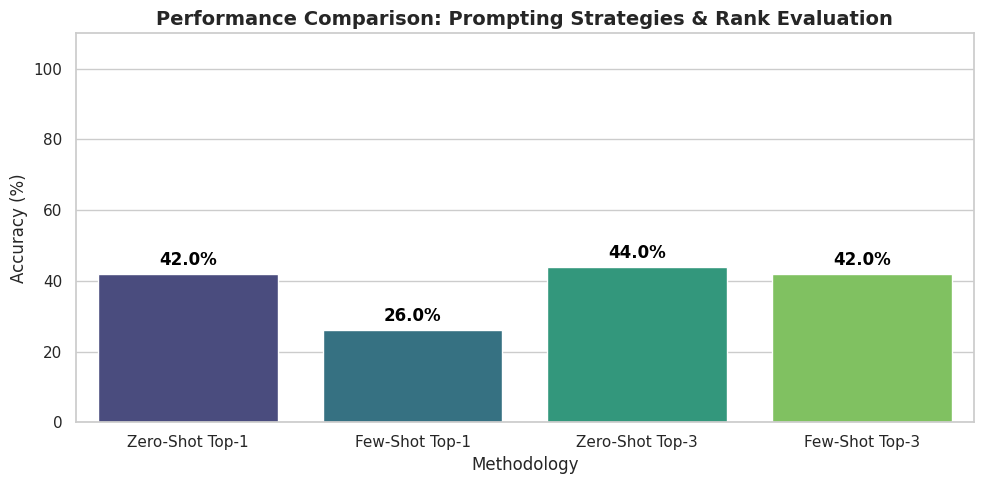

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

metrics_data = {
    'Methodology': ['Zero-Shot Top-1', 'Few-Shot Top-1', 'Zero-Shot Top-3', 'Few-Shot Top-3'],
    'Accuracy (%)': [
        accuracy_score(df['true_tag'], df['zero_shot_top_1']) * 100,
        accuracy_score(df['true_tag'], df['few_shot_top_1']) * 100,
        zero_shot_top3_acc,
        few_shot_top3_acc
    ]
}

metrics_df = pd.DataFrame(metrics_data)
ax = sns.barplot(x='Methodology', y='Accuracy (%)', data=metrics_df, palette='viridis')

plt.title('Performance Comparison: Prompting Strategies & Rank Evaluation', fontsize=14, fontweight='bold')
plt.ylim(0, 110)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                ha='center', va='center', fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()